In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import numpy as np

df = pd.read_csv(
    '/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/hashfrag/gosai/k562_gosai_filtered.csv.gz', compression='gzip'
)

# parse ref_minus_alt from list-string to float
df['ref_minus_alt_val'] = df['ref_minus_alt'].apply(lambda x: ast.literal_eval(x)[0] if isinstance(x, str) else float(x))

# pivot: rows = variant_id, cols = offset
pivot = df.pivot(index='variant_id', columns='offset', values='ref_minus_alt_val')
pivot.columns = [f'offset_{c}' for c in pivot.columns]
pivot.head()

,offset_-90,offset_-80,offset_-60,offset_-40,offset_-20,offset_0,offset_20,offset_40,offset_60,offset_80,offset_90
variant_id,,,,,,,,,,,
chr10_100267650_C_T,0.026845,0.072730,0.186770,0.151694,0.174582,0.172916,0.166853,0.220376,0.190836,0.186600,0.263313
chr10_101845957_T_C,0.639451,0.024758,-0.007379,-0.023714,-0.025672,-0.019105,-0.000928,-0.006313,0.009123,0.041691,0.046919
chr10_102006554_G_A,0.044979,0.116320,0.108721,0.123734,0.123386,0.108093,0.079807,0.061386,0.049458,0.077099,0.081190
chr10_103076162_C_T,0.170602,0.201895,0.226309,0.208401,0.190413,0.173059,0.059607,0.141463,0.200373,0.225215,0.070071
chr10_103587395_G_A,-0.044555,-0.001726,-0.025180,0.050364,-0.044934,-0.067808,-0.073069,-0.087521,-0.069858,-0.005615,0.003044


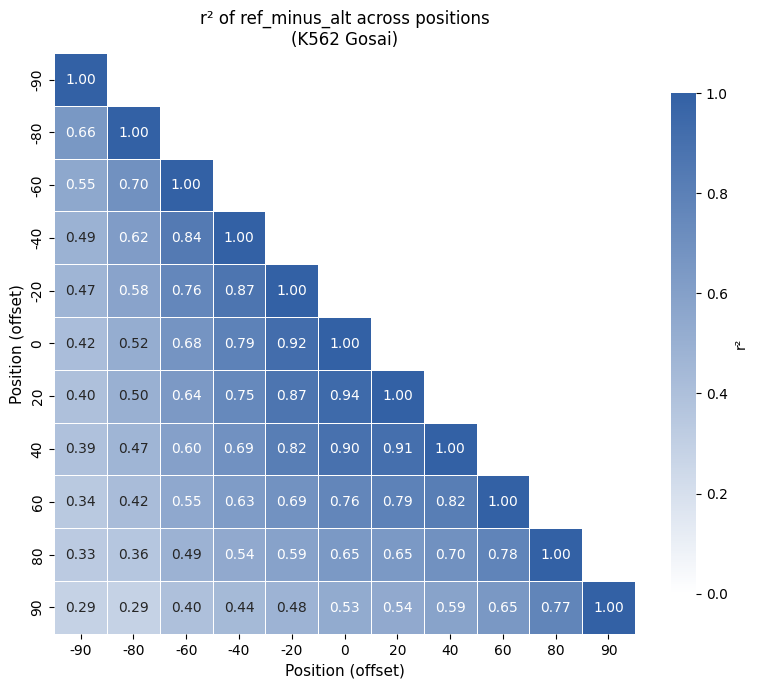

In [5]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

offsets = sorted(df['offset'].unique())  # -90 to 90

# r² matrix
corr = pivot[[f'offset_{o}' for o in offsets]].corr() ** 2
corr.index = offsets
corr.columns = offsets

# mask upper triangle (keep lower + diagonal)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

cmap = LinearSegmentedColormap.from_list('white_blue', ['#ffffff', '#3361A5'])

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmin=0, vmax=1,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    square=True,
    ax=ax,
    cbar_kws={'label': 'r²', 'shrink': 0.8},
)
ax.set_xlabel('Position (offset)', fontsize=11)
ax.set_ylabel('Position (offset)', fontsize=11)
ax.set_title('r² of ref_minus_alt across positions\n(K562 Gosai)', fontsize=12)
plt.tight_layout()
plt.savefig('k562_gosai_position_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
